In [1]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install -q pytesseract easyocr pandas pillow matplotlib opencv-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 90 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 29.8 MB/s eta 0:00:00


In [2]:
import os
import sys
import time
import cv2
import pandas as pd
import pytesseract
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
!rm -rf /content/medical-document-ocr-extraction
!git clone https://github.com/tarekmahfoudi/medical-document-ocr-extraction.git

Cloning into 'medical-document-ocr-extraction'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 109 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 6.25 MiB | 14.07 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [4]:
project_path = "/content/medical-document-ocr-extraction"

raw_path = os.path.join(
    project_path,
    "data",
    "raw",
    "sample"
)

processed_path = os.path.join(
    project_path,
    "data",
    "processed",
    "sample_preprocessed"
)

results_path = os.path.join(
    project_path,
    "results"
)

os.makedirs(processed_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

image_files = sorted([
    file
    for file in os.listdir(raw_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of images:", len(image_files))
print(image_files[:5])

Number of images: 20
['med_doc_bill_100400_noisy.jpg', 'med_doc_bill_100401_noisy.jpg', 'med_doc_bill_100402_noisy.jpg', 'med_doc_bill_100403_noisy.jpg', 'med_doc_bill_100406_noisy.jpg']


In [5]:
sample_files = image_files[:5]

print("Images selected:")
for filename in sample_files:
    print(filename)

Images selected:
med_doc_bill_100400_noisy.jpg
med_doc_bill_100401_noisy.jpg
med_doc_bill_100402_noisy.jpg
med_doc_bill_100403_noisy.jpg
med_doc_bill_100406_noisy.jpg


In [6]:
sys.path.append(
    os.path.join(project_path, "src")
)

from preprocess import preprocess_image

In [7]:
processed_files = {}

for filename in sample_files:
    input_path = os.path.join(
        raw_path,
        filename
    )

    output_filename = (
        os.path.splitext(filename)[0]
        + "_processed.jpg"
    )

    output_path = os.path.join(
        processed_path,
        output_filename
    )

    preprocess_image(
        input_path,
        output_path
    )

    processed_files[filename] = output_path

print("Preprocessing completed.")

Preprocessing completed.


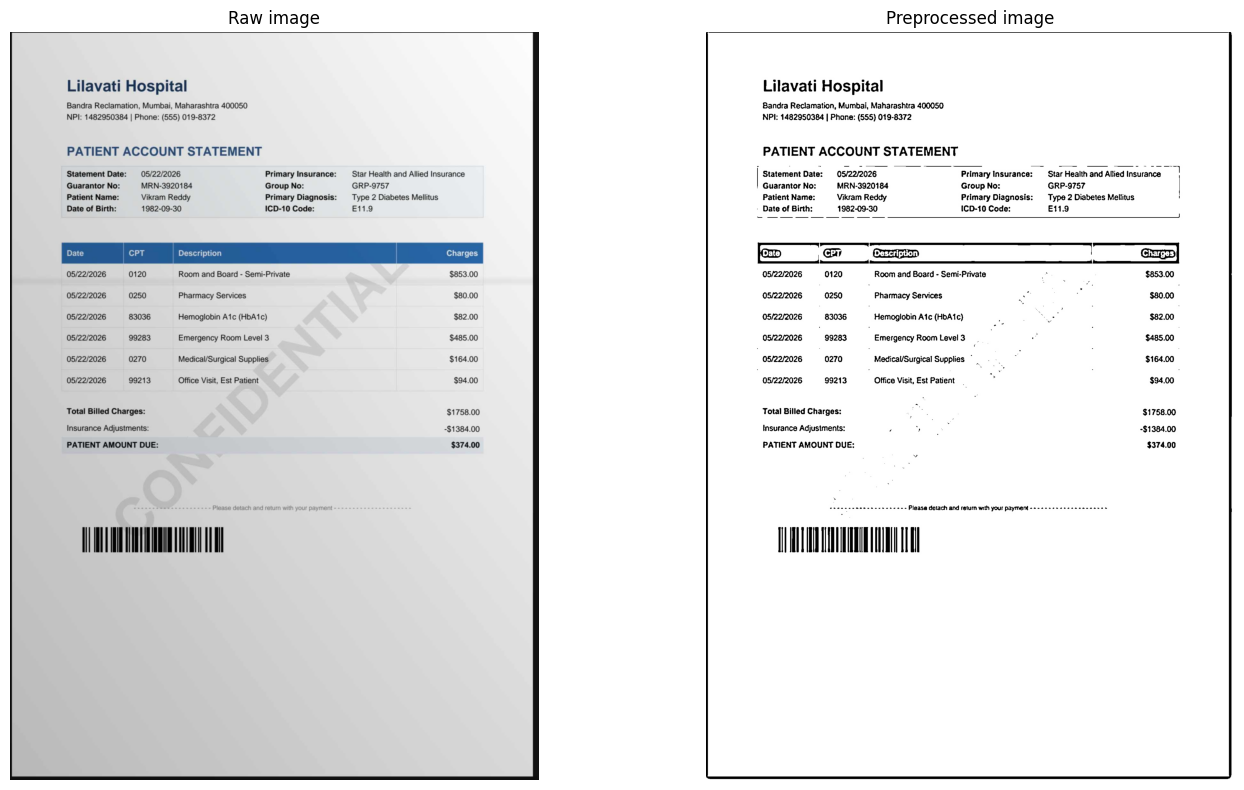

In [8]:
filename = sample_files[0]

raw_image = Image.open(
    os.path.join(raw_path, filename)
)

processed_image = Image.open(
    processed_files[filename]
)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(raw_image)
plt.axis("off")
plt.title("Raw image")

plt.subplot(1, 2, 2)
plt.imshow(processed_image, cmap="gray")
plt.axis("off")
plt.title("Preprocessed image")

plt.tight_layout()
plt.show()

In [9]:
reader = easyocr.Reader(
    ["en"],
    gpu=True
)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [10]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU name:",
        torch.cuda.get_device_name(0)
    )

GPU available: True
GPU name: Tesla T4


In [11]:
comparison_results = []

for filename in sample_files:

    image_versions = {
        "raw": os.path.join(
            raw_path,
            filename
        ),
        "preprocessed": processed_files[filename]
    }

    for image_type, image_path in image_versions.items():

        # Tesseract
        start_time = time.time()

        tesseract_text = pytesseract.image_to_string(
            Image.open(image_path),
            lang="eng"
        )

        tesseract_duration = (
            time.time() - start_time
        )

        comparison_results.append({
            "filename": filename,
            "engine": "tesseract",
            "device": "CPU",
            "image_type": image_type,
            "processing_time_seconds": tesseract_duration,
            "character_count": len(tesseract_text),
            "word_count": len(tesseract_text.split()),
            "ocr_text": tesseract_text
        })

        # EasyOCR
        start_time = time.time()

        easyocr_result = reader.readtext(
            image_path,
            detail=0
        )

        easyocr_text = " ".join(
            easyocr_result
        )

        easyocr_duration = (
            time.time() - start_time
        )

        comparison_results.append({
            "filename": filename,
            "engine": "easyocr",
            "device": "Tesla T4 GPU",
            "image_type": image_type,
            "processing_time_seconds": easyocr_duration,
            "character_count": len(easyocr_text),
            "word_count": len(easyocr_text.split()),
            "ocr_text": easyocr_text
        })

df_raw_processed = pd.DataFrame(
    comparison_results
)

df_raw_processed.head()

,filename,engine,device,image_type,processing_time_seconds,character_count,word_count,ocr_text
0,med_doc_bill_100400_noisy.jpg,tesseract,CPU,raw,2.479112,816,104,"\n\nLilavati Hospital\n\nBandra Reclamation, ..."
1,med_doc_bill_100400_noisy.jpg,easyocr,Tesla T4 GPU,raw,2.986458,826,110,"Lilavati Hospital Bandra Reclamation , Mumbai,..."
2,med_doc_bill_100400_noisy.jpg,tesseract,CPU,preprocessed,2.864921,843,122,"\n\nLilavati Hospital\n\nBandra Reclamation, ..."
3,med_doc_bill_100400_noisy.jpg,easyocr,Tesla T4 GPU,preprocessed,2.635206,817,107,"Lilavati Hospital Bandra Reclamation; Mumbai, ..."
4,med_doc_bill_100401_noisy.jpg,tesseract,CPU,raw,2.126060,703,87,"Apollo Health City\n\nJubilee Hills, Hyderabad..."


In [12]:
summary = (
    df_raw_processed
    .groupby(
        ["engine", "device", "image_type"]
    )
    .agg(
        mean_time=(
            "processing_time_seconds",
            "mean"
        ),
        mean_characters=(
            "character_count",
            "mean"
        ),
        mean_words=(
            "word_count",
            "mean"
        )
    )
    .reset_index()
)

summary

,engine,device,image_type,mean_time,mean_characters,mean_words
0,easyocr,Tesla T4 GPU,preprocessed,2.032302,712.0,94.0
1,easyocr,Tesla T4 GPU,raw,2.182263,721.2,96.4
2,tesseract,CPU,preprocessed,2.188435,705.0,98.8
3,tesseract,CPU,raw,2.178311,699.2,88.8


In [13]:
selected_filename = sample_files[0]

selected_results = df_raw_processed[
    df_raw_processed["filename"]
    == selected_filename
]

for _, row in selected_results.iterrows():

    print("=" * 100)
    print("ENGINE:", row["engine"])
    print("IMAGE TYPE:", row["image_type"])
    print("DEVICE:", row["device"])
    print("=" * 100)

    print(row["ocr_text"][:2000])
    print("\n")

ENGINE: tesseract
IMAGE TYPE: raw
DEVICE: CPU
 

Lilavati Hospital

Bandra Reclamation, Mumbai, Maharashtra 400050
NPI: 1482950384 | Phone: (555) 019-8372

PATIENT ACCOUNT STATEMENT

Statement Date: 05/22/2026 Primary Insurance:
Guarantor No: MRN-3920184 Group No:

Patient Name: Vikram Reddy Primary Diagnosis:
Date of Birth: 1982-09-30 ICD-10 Code:

BFC) ota els Tolg lected)

05/22/2026 0120 Room and Board - Semi-Private

05/22/2026 0250 Pharmacy Services

05/22/2026 83036 Hemoglobin A1c (HbA1c)

05/22/2026 99283 Emergency Room Level 3

05/22/2026 0270 Medical/Surgical Supplies

05/22/2026 99213 Office Visit, Est Patient

Total Billed Charges:
Insurance Adjustments:

PATIENT AMOUNT DUE:

 

Star Health and Allied Insurance
GRP-9757

Type 2 Diabetes Mellitus

E11.9

Charges
$853.00
$80.00
$82.00
$485.00
$164.00

$94.00

$1758.00
-$1384.00
$374.00

 



ENGINE: easyocr
IMAGE TYPE: raw
DEVICE: Tesla T4 GPU
Lilavati Hospital Bandra Reclamation , Mumbai, Maharashtra 400050 NPI: 1482950384 

In [14]:
results_csv = os.path.join(
    results_path,
    "ocr_raw_vs_preprocessed_results.csv"
)

df_raw_processed.to_csv(
    results_csv,
    index=False
)

print("Saved to:", results_csv)

Saved to: /content/medical-document-ocr-extraction/results/ocr_raw_vs_preprocessed_results.csv


In [15]:
summary_csv = os.path.join(
    results_path,
    "ocr_raw_vs_preprocessed_summary.csv"
)

summary.to_csv(
    summary_csv,
    index=False
)

print("Saved to:", summary_csv)

Saved to: /content/medical-document-ocr-extraction/results/ocr_raw_vs_preprocessed_summary.csv


## Raw versus preprocessed image comparison

This experiment compares Tesseract and EasyOCR on raw and preprocessed medical document images.

The preprocessing pipeline includes grayscale conversion, median denoising and adaptive thresholding.

The comparison focuses on:

- processing time;
- amount of extracted text;
- qualitative readability of OCR outputs;
- differences between raw and preprocessed images.

Character and word counts are descriptive indicators only. A higher number of extracted words does not necessarily indicate better OCR accuracy.

The effect of preprocessing may differ depending on the document layout, noise level, contrast and OCR engine.